## Building Classification with GeoAI — Google AlphaEarth in Python

In this tutorial, you will find my most thorough GeoAI workflow yet, using Google Earth 𝐀𝐥𝐩𝐡𝐚𝐄𝐚𝐫𝐭𝐡 for urban data science.

We will start by downloading the AlphaEarth data directly in Python, without any third-party tools, and then combine it with OpenStreetMap building footprints.

Quick recap: Google AlphaEarth is Google’s brand-new GeoAI Earth observation initiative that combines petabytes of satellite imagery and remote sensing to present large-scale, global, 10x10m-resolution multispectral (64 bands for starters) data.

Leveraging this kind of data, due to its small-scale spatial resolution and high feature variance, it’s probably going to be a game-changer for data-driven urban planning. It allows data scientists and city planners alike to characterize urban-scale areas all around the world with high precision and harness a rich set of features for planning, predictive modeling, and many other applications — especially if combined with the right vector data.

To get to the point, in this tutorial, you will

- Learn how to acquire and explore AlphaEarth data in Python

- Match that data to real buildings,

- Visualize the results through interactive Folium maps, and

Build a simple binary building classification model using GeoPandas, Earth Engine, and scikit-learn.

## 0. Let’s set up our environment!

In [1]:
# Geospatial and mapping libraries
import geopandas as gpd
from shapely.geometry import mapping, shape
import osmnx as ox
import folium
import ee

# Data handling and analysis
import pandas as pd
import numpy as np
from collections import Counter
import random

# Machine learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image

# External data and requests
import requests

## 1. Get Google AlphaEarth data

In [3]:
ee.Authenticate() 

ee.Initialize(project=yourproject)
admin = ox.geocode_to_gdf("Budapest")
geom = admin.iloc[0].geometry
admin.plot()

Exception: Problem requesting tokens. Please try again. HTTP Error 400: Bad Request b'{\n  "error": "invalid_request",\n  "error_description": "Missing required parameter: code"\n}'

In [5]:
roi = ee.Geometry(mapping(geom))
print('ROI bounds:', roi.bounds().getInfo())

dataset = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')

img_2024 = (
    dataset
    .filterDate('2024-01-01', '2025-01-01')
    .filterBounds(roi)
    .mean()
    .clip(roi)
)

print(img_2024.bandNames().getInfo())
print(img_2024.getInfo())

NameError: name 'geom' is not defined

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(arr)
plt.title('AlphaEarth 2024 RGB composite (A00–A16–A09)')
plt.axis('off')
plt.show()

## 2. Get buildings from OSM

Number of buildings: 1077


geometry access  \
element  id                                                                     
node     263960784                           POINT (19.05099 47.50945)    yes   
relation 11764       POLYGON ((19.04682 47.51195, 19.04678 47.5118,...    NaN   
         11766       POLYGON ((19.0481 47.50746, 19.04812 47.50746,...    NaN   
         11768       POLYGON ((19.04557 47.50473, 19.04596 47.50477...    NaN   
         11772       POLYGON ((19.04612 47.50149, 19.04623 47.5015,...    NaN   
...                                                                ...    ...   
way      1530362281  POLYGON ((19.05148 47.49589, 19.05127 47.49581...    NaN   
         1530362284  POLYGON ((19.05176 47.49568, 19.05161 47.49595...    NaN   
         1533591995  POLYGON ((19.05334 47.49135, 19.05349 47.49139...    NaN   
         1536618567  POLYGON ((19.05275 47.50478, 19.05282 47.50479...    NaN   
         1536618568  POLYGON ((19.0527 47.50494, 19.05278 47.50495,...    NaN   

                     amenity    building   charge drinking_water  fee  \
element  id                                                             
node     263960784   toilets     toilets  250 HUF             no  yes   
relation 11764           NaN      office      NaN            NaN  NaN   
         11766           NaN         yes      NaN            NaN  NaN   
         11768           NaN  apartments      NaN            NaN  NaN   
         11772           NaN         yes      NaN            NaN  NaN   
...                      ...         ...      ...            ...  ...   
way      1530362281      NaN  apartments      NaN            NaN  NaN   
         1530362284      NaN  apartments      NaN            NaN  NaN   
         1533591995      NaN  apartments      NaN            NaN  NaN   
         1536618567      NaN         yes      NaN            NaN  NaN   
         1536618568      NaN         yes      NaN            NaN  NaN   

                    handwashing:creme handwashing:hand_cleaning_paste  \
element  id                                                             
node     263960784                 no                              no   
relation 11764                    NaN                             NaN   
         11766                    NaN                             NaN   
         11768                    NaN                             NaN   
         11772                    NaN                             NaN   
...                               ...                             ...   
way      1530362281               NaN                             NaN   
         1530362284               NaN                             NaN   
         1533591995               NaN                             NaN   
         1536618567               NaN                             NaN   
         1536618568               NaN                             NaN   

                    handwashing:hand_disinfection  ... castle_type  \
element  id                                        ...               
node     263960784                             no  ...         NaN   
relation 11764                                NaN  ...         NaN   
         11766                                NaN  ...         NaN   
         11768                                NaN  ...         NaN   
         11772                                NaN  ...         NaN   
...                                           ...  ...         ...   
way      1530362281                           NaN  ...         NaN   
         1530362284                           NaN  ...         NaN   
         1533591995                           NaN  ...         NaN   
         1536618567                           NaN  ...         NaN   
         1536618568                           NaN  ...         NaN   

                    building:flats image url:muemlekem basilica  \
element  id                                                       
node     263960784             NaN   NaN           NaN      NaN

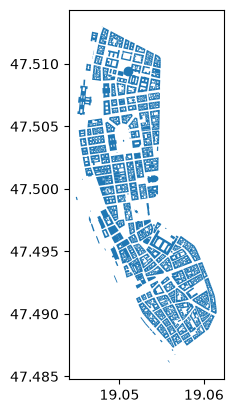

In [7]:
admin = ox.geocode_to_gdf("5th District, Budapest")
geom = admin.iloc[0].geometry

buildings = ox.features_from_polygon(geom, tags={"building": True})
buildings.plot()
print('Number of buildings:', len(buildings))
buildings

In [ ]:
buildings = buildings[buildings.geometry.type.isin([{"type": "Polygon"}, {"type": "MultiPolygon"}])].copy()
buildings = buildings.reset_index()
buildings["osmid"] = buildings["id"]
keep_cols = ["osmid", "building", "amenity", "geometry"]
buildings = buildings[keep_cols]
buildings = buildings.drop_duplicates(subset=["osmid"]).dropna(subset=["geometry"])
buildings = buildings.reset_index(drop=True)

print(f"✅ Cleaned number of buildings: {len(buildings)}")

## 3. Map AlphaEarth features into footprints

In [ ]:
results = []

for start in range(0, len(buildings), 100):
    subset = buildings.iloc[start:start+100]

    fc = ee.FeatureCollection([
        ee.Feature(ee.Geometry(mapping(geom)), {"osmid": int(osmid)})
        for osmid, geom in zip(subset["osmid"], subset.geometry)
    ])

    stats = (
        img_2024
        .select([f”A{str(b).zfill(2)}” for b in range(64)])
        .reduceRegions(collection=fc, reducer=ee.Reducer.mean(), scale=10)
        .getInfo()
    )

    for f in stats.get("features", []):
        props = f.get("properties", {}) or {}
        geom = f.get("geometry")
        if geom:
            props["geometry"] = shape(geom)
            results.append(props)

buildings_alphaearth = gpd.GeoDataFrame(results, crs="EPSG:4326")
len(buildings_alphaearth)
buildings_alphaearth.head()

buildings_alphaearth = buildings_alphaearth[buildings_alphaearth.geometry.type == "Polygon"]

In [ ]:
m = folium.Map(
    location=[
        buildings_alphaearth.geometry.centroid.y.mean(),
        buildings_alphaearth.geometry.centroid.x.mean()
    ],
    zoom_start=14,
    tiles="cartodbpositron"
)

bands = [f"A{str(i).zfill(2)}" for i in range(64)]



for band in bands:

    cmap = mcolors.LinearSegmentedColormap.from_list('trippy', [random.choice(list(mcolors.CSS4_COLORS.values())) for _ in range(5)])
    vmin, vmax = buildings_alphaearth[band].min(), buildings_alphaearth[band].max()
    gjson = buildings_alphaearth[[band, "geometry"]].to_json()

    def style_fn(x, band=band, cmap=cmap, vmin=vmin, vmax=vmax):
        val = x["properties"].get(band)
        if val is None or np.isnan(val):
            color = "#000000"
        else:
            rgba = cmap((val - vmin) / (vmax - vmin))
            color = mcolors.rgb2hex(rgba)
        return {"fillColor": color, "color": color, "weight": 0.1, "fillOpacity": 0.7}

    
    folium.GeoJson(
            gjson,
            name=f"{band}",
            style_function=style_fn,
            tooltip=folium.GeoJsonTooltip(fields=[band])
        ).add_to(m)


layer_control = folium.LayerControl(collapsed=False)
layer_control.add_to(m)

for key in list(m._children):
    if key.startswith('feature_group') or key.startswith('geo_json'):
        m._children[key].show = False

m

## 4. Building type prediction

In [ ]:
display(buildings[["osmid", "amenity", "building"]])
Counter(buildings.dropna(subset = ["building"]).building).most_common()

In [ ]:
df = buildings_alphaearth.copy()
df = df.merge(buildings, left_on = 'osmid', right_on = 'osmid')
df = df[df["building"].isin(["office", "university"])].reset_index(drop=True)
df = df.drop(columns = ['geometry_x', 'geometry_y'])

features = [f"A{str(i).zfill(2)}" for i in range(64)]
X = df[features].values
y = (df["building"] == "office").astype(int)  # office=1, university=0

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA().fit(X_scaled)

explained_var = np.cumsum(pca.explained_variance_ratio_) * 100

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker="o", color="steelblue")
plt.axhline(90, color="red", linestyle="--", label="90% variance threshold")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Elbow Plot")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [ ]:
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_bal, y_bal = ros.fit_resample(X_pca, y)

X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)

clf = SVC(kernel=”rbf”, C=1, gamma=”scale”, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))